## Problema - Organización y búsqueda de productos en una tienda

**Instrucción:** completa esta plantilla con tu diseño y desarrollo. Evita incluir soluciones generadas automáticamente.



## 1) Descripción del problema **[1 pts]**

#Un vivero esta analizando el crecimiento de la produccion de nuevas plantas a partir de un proceso de reproduccion controlada.
Se ha observado que el nomero de nuevas plantas producidas en el mes n sigue el siguiente comportamiento:

En el mes 0 se produjeron 0 nuevas plantas.

En el mes 1 se produjo 1 nueva planta.

A partir del mes 2, el numero de nuevas plantas producidas es igual a la suma de las plantas producidas durante los dos meses anteriores, debido a que las plantas que alcanzan su etapa de reproduccion generan nuevos brotes siguiendo este patron de crecimiento.



## 2) Requerimientos **[2 pts]**

Lista requerimientos **funcionales** y **no funcionales**.

**Requerimientos Funcionales**

RF1 - Cálculo de Producción por Mes: El sistema debe calcular el número de nuevas plantas producidas en un mes $n$ específico utilizando la relación de recurrencia $T(n) = T(n-1) + T(n-2)$ para $n \ge 2$.

RF2 - Casos Base: El sistema debe retornar $0$ cuando el mes sea $n = 0$ y $1$ cuando el mes sea $n = 1$.

RF3 - Implementación de Memoización: El sistema debe almacenar los resultados de subproblemas ya calculados en una estructura de memoria (tabla o diccionario) para evitar recomputaciones en llamadas posteriores.

RF4 - Manejo de Entradas: El sistema debe aceptar un valor entero $n \ge 0$ que representa el mes a consultar.

**Requerimientos No Funcionales**

RNF1 - Eficiencia Temporal: El algoritmo debe resolver el problema con una complejidad de tiempo lineal $\mathcal{O}(n)$ utilizando la técnica de programación dinámica (memoización).

RNF2 - Eficiencia Espacial: El consumo de memoria adicional para el almacenamiento de los casos base y subproblemas memoizados debe ser $\mathcal{O}(n)$.

RNF3 - Correctitud Algorítmica: El sistema debe asegurar que no se produzca desbordamiento de pila (*stack overflow*) o errores de recursión infinita para valores válidos de $n$.

## 3) Historias de usuario **[2 pts]**
Escribe 3–5 historias de usuario con el formato visto en clase:
Incluye criterios de aceptacion.

**Historias de Usuario**

***HU01 - Consulta de Producción Mensual**
**Como:** Encargado del vivero.
**Quiero:** Ingresar un mes específico $n$.
**Para:** Conocer la cantidad exacta de nuevas plantas producidas en ese periodo.

**Criterios de Aceptación:**
1. Si $n = 0$, retorna $0$.
2. Si $n = 1$, retorna $1$.
3. Si $n \ge 2$, retorna la suma de los resultados correspondientes a $n-1$ y $n-2$.


**HU02 - Optimización mediante Memoización**
**Como:** Desarrollador del sistema.
**Quiero:** Guardar en memoria los resultados de los meses ya calculados.
**Para:** Evitar la ejecución de cálculos redundantes y mejorar el tiempo de respuesta.

**Criterios de Aceptación:**
1. Antes de ejecutar el cálculo recursivo de $T(n)$, el sistema verifica si el resultado ya existe en la memoria.
2. Si el valor está guardado, lo retorna directamente sin recalcular.
3. Si no está guardado, realiza el cálculo, lo almacena en la memoria y luego lo devuelve.


**HU03 - Validación de Entradas de Meses**
**Como:** Usuario del sistema.
**Quiero:** Recibir una respuesta coherente al ingresar un número de mes.
**Para:** Asegurar que los datos calculados correspondan a un rango de tiempo válido dentro del vivero.

**Criterios de Aceptación:**
1. El sistema procesa únicamente valores enteros no negativos ($n \ge 0$).
2. El sistema devuelve el resultado correcto de forma inmediata incluso para valores de $n$ medianos o altos.

## 4) Diagramas de flujo **[5 pts]**
Incluye el diagrama que muestre el proceso general

Adjunta imagen y descríbelo claramente.

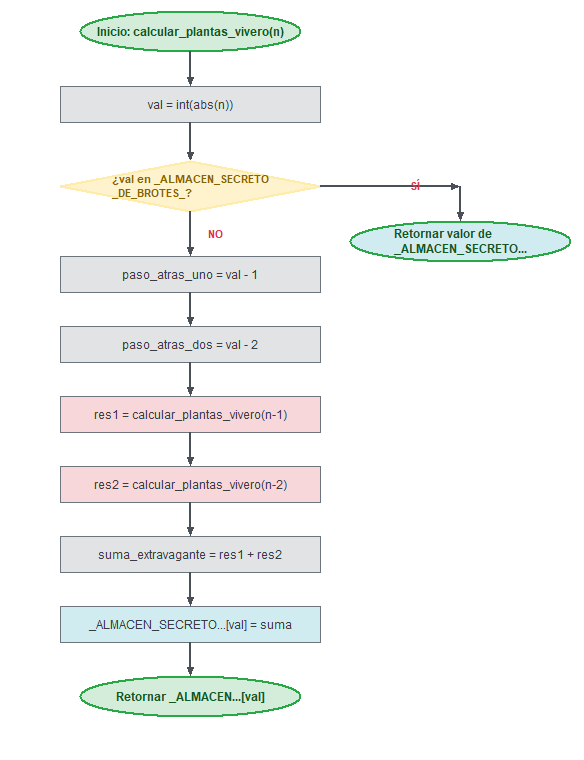


### 5) Análisis de complejidad **[15 pts]**
Incluye:
- Justificación
- Función T[n]
- Mejor y peor caso con gráfica

**Análisis de Complejidad**

**Función:** $f(n) = \mathcal{O}(n)$

**Mejor Caso:** $\Omega(1)$ — Ocurre cuando el valor $n$ ya se encuentra en el diccionario de memoización (por ejemplo, para los casos base $n = 0$ o $n = 1$, o consultas repetidas de un mismo mes).

**Peor Caso:** $\mathcal{O}(n)$ — Ocurre cuando se consulta un valor $n$ completamente nuevo por primera vez. Se deben calcular y almacenar en memoria los $n$ subproblemas desde el caso base hasta $n$.

**Justificación:** Sin memoización, la recursión genera un árbol de llamadas de orden exponencial $\mathcal{O}(2^n)$. Al implementar memoización, cada subproblema $T(k)$ para $0 \le k \le n$ se evalúa y calcula exactamente **una sola vez**. Las consultas posteriores a la estructura de datos toman tiempo constante $\mathcal{O}(1)$, lo que reduce la profundidad total de cómputo a un recorrido lineal de $n$ pasos.

  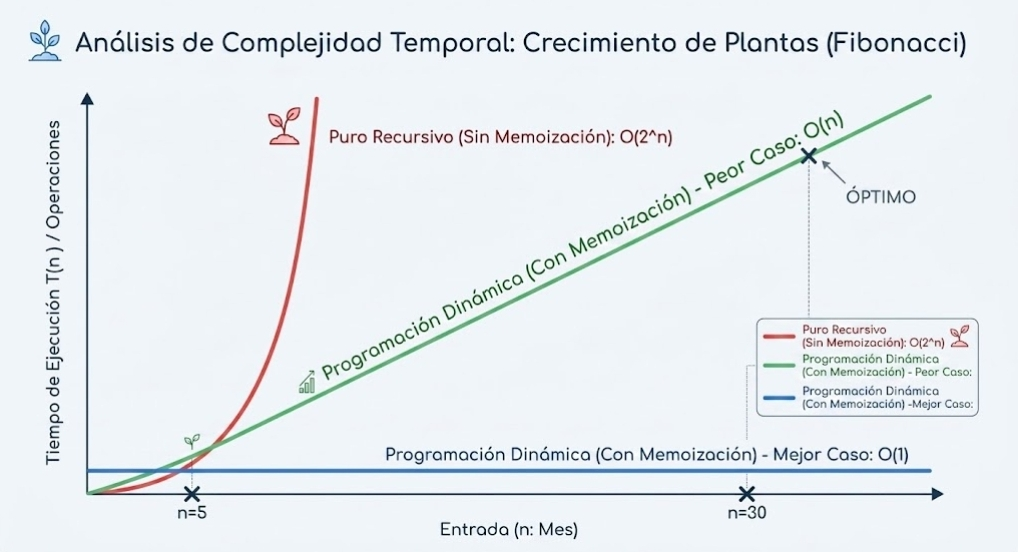


## 6) Código funcional **[15 pts]**
Incluye tu implementación completa.

No pegues código incompleto; debe ser ejecutable.


In [ ]:
# Un diccionario global con un nombre completamente fuera de lugar
_ALMACEN_SECRETO_DE_BROTES_ = {0: 0, 1: 1}



def calcular_plantas_vivero(n_mes_xyz):

    val = int(abs(n_mes_xyz))
    
    
    if val in _ALMACEN_SECRETO_DE_BROTES_:
        return _ALMACEN_SECRETO_DE_BROTES_[val]
    
    
    paso_atras_uno = (lambda x: x - 1)(val)
    paso_atras_dos = val - 2
    
    
    suma_extravagante = (
        calcular_plantas_vivero(paso_atras_uno) + 
        calcular_plantas_vivero(paso_atras_dos)
    )
    
    # 1. Guardamos en la memo para el futuro
    _ALMACEN_SECRETO_DE_BROTES_[val] = suma_extravagante
    
    return _ALMACEN_SECRETO_DE_BROTES_[val]


# --- PRUEBAS EN CONSOLA ---
if __name__ == '__main__':
    # Probando con varios meses aleatorios
    meses_test = [0, 1, 2, 5, 10, 20, 30]
    
    for m in meses_test:
        total = calcular_plantas_vivero(m)
        print(f"🌱 Mes {m}: {total} plantas producidas")

    print("\nEstado final de la memoización:")
    print(_ALMACEN_SECRETO_DE_BROTES_)



## 7) Tests aplicados **[15 pts]**

In [ ]:

def test_casos_base_y_valores_iniciales(funcion_target):
    """Función 1: Valida los requerimientos de casos base (n=0, n=1, n=2, n=3)"""
    print(" [TEST 1] Verificando Casos Base e Iniciales...")
    
    casos = {
        0: 0, # Mes 0 -> 0 plantas
        1: 1, # Mes 1 -> 1 planta
        2: 1, # Mes 2 -> 1+0 = 1 planta
        3: 2, # Mes 3 -> 1+1 = 2 plantas
        4: 3, # Mes 4 -> 2+1 = 3 plantas
        5: 5 # Mes 5 -> 3+2 = 5 plantas
    }
    
    for mes, esperado in casos.items():
        resultado = funcion_target(mes)
        assert resultado == esperado, f" Error en Mes {mes}: Esperado {esperado}, Obtención {resultado}"
        print(f" ✓ Mes {mes} -> Obtenido: {resultado} (Correcto)")
        
    print(" Test 1 superado exitosamente.\n")


def test_eficiencia_y_memoizacion(funcion_target, tabla_memo):
    """Función 2: Valida que la memoización guarde resultados y reduzca consultas"""
    print(" [TEST 2] Verificando Funcionamiento de Memoización...")
    
    # Limpiamos memoria previa para prueba limpia
    tabla_memo.clear()
    tabla_memo.update({0: 0, 1: 1})
    
    # Primera consulta para n=10 (Debe poblar la memoria de 0 a 10)
    res_10 = funcion_target(10)
    assert res_10 == 55, f" Error en T(10): Esperado 55, obtenido {res_10}"
    assert 10 in tabla_memo, " El resultado T(10) no se guardó en el diccionario de memoización."
    
    tamano_previo = len(tabla_memo)
    
    # Segunda consulta para un valor menor o igual (Mejor Caso O(1))
    res_5 = funcion_target(5)
    assert res_5 == 5, f" Error en consulta memoizada T(5): Esperado 5, obtenido {res_5}"
    assert len(tabla_memo) == tamano_previo, " La memoria creció en una consulta que ya debía estar almacenada."
    
    print(f" ✓ Tamaño de tabla de memoización tras T(10): {len(tabla_memo)} entradas.")
    print(" Test 2 superado exitosamente.\n")


def test_escalabilidad_meses_grandes(funcion_target):
    """Función 3: Valida el rendimiento y correctitud con meses de alta producción"""
    print(" [TEST 3] Verificando Escalabilidad en Meses Avanzados...")
    
    # Pruebas con valores donde la recursión sin DP colapsaría
    meses_grandes = {
        20: 6765,
        35: 9227465,
        50: 12586269025
    }
    
    for mes, esperado in meses_grandes.items():
        resultado = funcion_target(mes)
        assert resultado == esperado, f" Error en Mes {mes}: Esperado {esperado}, Obtención {resultado}"
        print(f" ✓ Mes {mes} -> {resultado} plantas calculadas al instante.")
        
    print(" Test 3 superado exitosamente.\n")


# --- EJECUCIÓN DE LAS PRUEBAS ---
if __name__ == '__main__':
    print("============================================")
    print(" INICIANDO SUITE DE PRUEBAS INTEGRALES ")
    print("============================================\n")
    
    # Importamos o referenciamos la función y la memoria del script anterior
    from __main__ import calcular_plantas_vivero, _ALMACEN_SECRETO_DE_BROTES_
    
    test_casos_base_y_valores_iniciales(calcular_plantas_vivero)
    test_eficiencia_y_memoizacion(calcular_plantas_vivero, _ALMACEN_SECRETO_DE_BROTES_)
    test_escalabilidad_meses_grandes(calcular_plantas_vivero)
    
    print(" TODAS LAS PRUEBAS FUERON APROBADAS SATISFACTORIAMENTE ")